In [35]:
# Import libraries 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [36]:
# Load the cleaned and one-hot encoded dataset created during Week 3
df = pd.read_csv("data/cleaned_sold_single_family.csv")

print("Dataset shape:", df.shape)

# Preview the first five rows
df.head()

Dataset shape: (55488, 968)


,CloseDate,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,DaysOnMarket,CloseMonth,City_Acampo,...,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba
0,2025-12-31,1998000.0,2045.0,4.0,2.0,10080.0,1968.0,0,2025-12,False,...,False,False,False,False,False,False,False,False,False,False
1,2025-12-31,2214421.0,3050.0,4.0,4.0,34745.0,1957.0,0,2025-12,False,...,False,False,False,False,False,False,False,False,False,False
2,2025-12-31,1200000.0,1594.0,4.0,2.0,6600.0,1978.0,0,2025-12,False,...,False,False,False,False,False,False,False,False,False,False
3,2025-12-31,3100000.0,2700.0,5.0,3.0,8262.0,2025.0,0,2025-12,False,...,False,False,False,False,False,False,False,False,False,False
4,2025-12-31,2900000.0,2948.0,5.0,4.0,9222.0,2023.0,0,2025-12,False,...,False,False,False,False,False,False,False,False,False,False


In [37]:
# Check the data types in the cleaned dataset
df.dtypes.value_counts()

bool       959
float64      6
object       2
int64        1
Name: count, dtype: int64

In [38]:
# Check for any remaining missing values
remaining_missing = df.isnull().sum()

# Display only columns that still contain missing values
remaining_missing[remaining_missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [39]:
# Select a small group of core numerical property features
# for the baseline Linear Regression model
baseline_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "DaysOnMarket"
]

# Set the input features
X = df[baseline_features].copy()

# Set the target variable
y = df["ClosePrice"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (55488, 6)
Target shape: (55488,)


In [40]:
# Convert ClosePrice to numeric in case it was loaded as text
y = pd.to_numeric(y, errors="coerce")

In [41]:
# Split the dataset into training and testing sets
# 80% of the data is used for training
# 20% is reserved for model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (44390, 6)
Testing set shape: (11098, 6)


In [42]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler using only the training data
# and transform the training features
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


In [43]:
# Initialize the baseline Linear Regression model
linear_model = LinearRegression()

# Train the model using the scaled training data
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model training complete.")

Linear Regression model training complete.


In [44]:
# Predict closing prices for the test set
y_pred = linear_model.predict(X_test_scaled)

# Display the first five predictions
print(y_pred[:5])

[3022385.88788212 1935463.55966576  790000.03997132  385957.86296805
  933093.08053203]


In [45]:
# Evaluate the baseline model using R-squared
r2 = r2_score(y_test, y_pred)

print("Baseline Linear Regression Results")
print("----------------------------------")
print(f"R² Score: {r2:.4f}")

Baseline Linear Regression Results
----------------------------------
R² Score: 0.4673


In [46]:
# Store the baseline model results
baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Features": [", ".join(baseline_features)],
    "R2": [r2]
})

baseline_results

,Model,Features,R2
0,Linear Regression,"LivingArea, BedroomsTotal, BathroomsTotalInteg...",0.467288


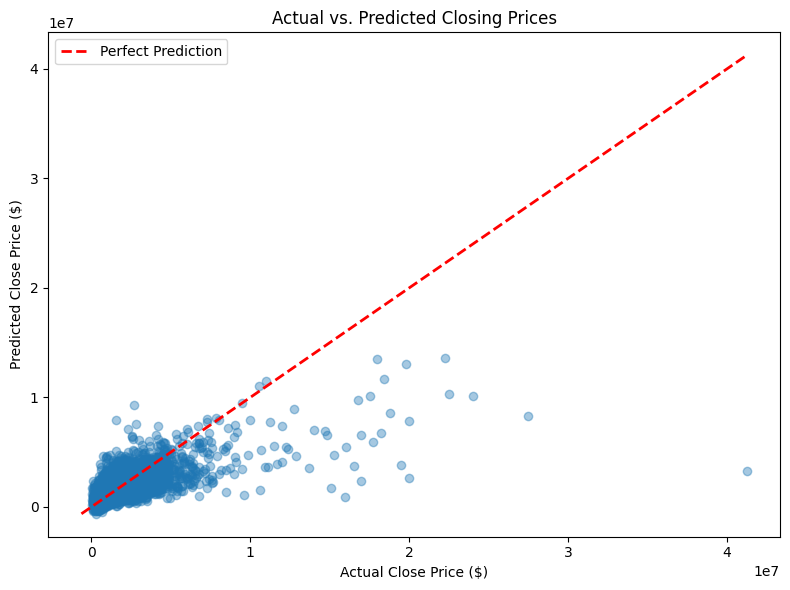

In [47]:
# Create a scatter plot comparing actual and predicted closing prices
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

# Plot the ideal prediction line (y = x)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

# Add labels and title
plt.title("Actual vs. Predicted Closing Prices")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.legend()

plt.tight_layout()
plt.show()